# Border-03-TinyML-Training
## Edge AI-Based Acoustic Footstep Detection for Border Surveillance
### Notebook 03 · Model Training, Quantisation & Deployment Profiling

**Pipeline position:** EDA → Preprocessing → **Training ← (you are here)** → Deployment

**Inputs:** `features_train.npz`, `features_val.npz`, `features_test.npz`  
**Outputs:** `border_model.tflite` (INT8), `border_model_float.tflite`, evaluation figures, classification report

**TinyML target:** ESP32 (240 MHz, ~320 KB SRAM, ~4 MB Flash)

In [2]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings, os, time, itertools, json, struct
warnings.filterwarnings("ignore")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.utils import to_categorical
print(f"TensorFlow {tf.__version__}  |  Keras {keras.__version__}")

# Sklearn metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────────────────
INPUT_PATH   = "/kaggle/input/borderintrusiondetection-data"
WORKING_PATH1 = "/kaggle/input/datasets/katakuricharlotte/border-preprocessed-data/processed"
WORKING_PATH ="/kaggle/working/"
FIGURES_PATH = "/kaggle/working/figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

# ── Paper-ready plot styling ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#FFFFFF",
    "grid.linewidth": 1.2,
    "grid.alpha": 0.7,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#CCCCCC",
    "lines.linewidth": 1.8,
    "patch.linewidth": 0.5,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
})

CLASS_COLORS = {"balastic": "#2196F3", "footsteps": "#FF9800", "noise": "#4CAF50"}
CLASS_NAMES  = ["balastic", "footsteps", "noise"]
PALETTE      = [CLASS_COLORS[c] for c in CLASS_NAMES]

def paper_axes(ax):
    ax.set_facecolor("#F8F9FA")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
        spine.set_linewidth(0.8)
    ax.grid(True, color="white", linewidth=1.2, alpha=0.7)
    ax.tick_params(colors="#444444")
    ax.title.set_color("#222222")
    ax.xaxis.label.set_color("#444444")
    ax.yaxis.label.set_color("#444444")
    return ax

print("✓ Styling loaded  |  TF", tf.__version__)

TensorFlow 2.19.0  |  Keras 3.10.0
✓ Styling loaded  |  TF 2.19.0


In [3]:
def load_split(tag):
    d = np.load(f"{WORKING_PATH1}/features_{tag}.npz", allow_pickle=True)
    X       = d["X"].astype(np.float32)
    y       = d["y_enc"].astype(np.int64)      # integer-encoded labels
    classes = d["classes"]                      # ['balastic' 'footsteps' 'noise']
    return X, y, classes

X_train, y_train, label_names = load_split("train")
X_val,   y_val,   _           = load_split("val")
X_test,  y_test,  _           = load_split("test")

N_CLASSES  = len(label_names)
N_FEATURES = X_train.shape[1]

CLASS_NAMES  = list(label_names)                # ['balastic', 'footsteps', 'noise']
CLASS_COLORS = {"balastic": "#2196F3", "footsteps": "#FF9800", "noise": "#4CAF50"}
PALETTE      = [CLASS_COLORS[c] for c in CLASS_NAMES]

print(f"Feature dim  : {N_FEATURES}")
print(f"Classes      : {CLASS_NAMES}  ({N_CLASSES})")
print(f"Train        : {X_train.shape}   labels={np.bincount(y_train)}")
print(f"Val          : {X_val.shape}     labels={np.bincount(y_val)}")
print(f"Test         : {X_test.shape}    labels={np.bincount(y_test)}")

# One-hot encode for Keras
Y_train = to_categorical(y_train, N_CLASSES)
Y_val   = to_categorical(y_val,   N_CLASSES)
Y_test  = to_categorical(y_test,  N_CLASSES)

print("\n✓ All splits loaded successfully")

Feature dim  : 24
Classes      : ['balastic', 'footsteps', 'noise']  (3)
Train        : (775, 24)   labels=[261 296 218]
Val          : (99, 24)     labels=[56 12 31]
Test         : (100, 24)    labels=[57 12 31]

✓ All splits loaded successfully


## Stage 1 — Feature Distribution & Class Balance Audit

Before training, confirm that normalised features are well-conditioned and
classes are balanced across all splits.

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Feature Space Audit — Pre-Training Verification",
             fontsize=14, fontweight="bold", y=1.01)

# (a) Per-class feature mean ± std heatmap
ax = axes[0, 0]
means = np.array([X_train[y_train == i].mean(axis=0) for i in range(N_CLASSES)])
im = ax.imshow(means, aspect="auto", cmap="RdYlBu_r")
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Feature Index"); ax.set_title("(a) Per-Class Feature Means")
plt.colorbar(im, ax=ax, shrink=0.85)
paper_axes(ax)

# (b) Feature variance across train set
ax = axes[0, 1]
vars_ = X_train.var(axis=0)
ax.bar(range(N_FEATURES), vars_, color="#5C6BC0", alpha=0.8, edgecolor="none")
ax.set_xlabel("Feature Index"); ax.set_ylabel("Variance")
ax.set_title("(b) Feature Variance (Train)")
paper_axes(ax)

# (c) Class counts per split
ax = axes[1, 0]
split_names = ["Train", "Val", "Test"]
ys = [y_train, y_val, y_test]
x = np.arange(N_CLASSES); width = 0.25
for si, (sn, y_s) in enumerate(zip(split_names, ys)):
    counts = np.bincount(y_s, minlength=N_CLASSES)
    ax.bar(x + si*width, counts, width, label=sn,
           color=["#42A5F5","#FFA726","#66BB6A"][si], alpha=0.85, edgecolor="none")
ax.set_xticks(x + width); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("Count"); ax.set_title("(c) Class Distribution per Split")
ax.legend(); paper_axes(ax)

# (d) PairPlot proxy — scatter first 3 MFCCs coloured by class
ax = axes[1, 1]
for i, cn in enumerate(CLASS_NAMES):
    idx = y_train == i
    ax.scatter(X_train[idx, 0], X_train[idx, 1],
               c=PALETTE[i], label=cn, alpha=0.5, s=18, edgecolors="none")
ax.set_xlabel("Feature 0 (MFCC-1 mean)")
ax.set_ylabel("Feature 1 (MFCC-2 mean)")
ax.set_title("(d) Feature 0 vs 1 — Train")
ax.legend(); paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_feature_audit.png")
plt.show()
print("Saved → fig_feature_audit.pdf")

Saved → fig_feature_audit.pdf


## 
Stage 2 — Model Architecture Design

Three architectures are trained and compared under TinyML constraints:

| Model | Architecture | Target use |
|---|---|---|
| **MLP-Tiny** | 3-layer MLP (64→32→16) | Baseline, smallest footprint |
| **MLP-Deep** | 5-layer MLP with BatchNorm + Dropout | Best accuracy |
| **MLP-BN** | 3-layer MLP + BatchNorm (no Dropout) | Fast inference |

All models use **24-dim** input → **3-class** softmax output.  
Post-training **INT8 quantisation** targets ESP32 SRAM < 50 KB.

In [5]:
def build_mlp_tiny(input_dim=24, n_classes=3):
    inp = keras.Input(shape=(input_dim,), name="input")
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    model = keras.Model(inp, out, name="MLP_Tiny")
    return model

def build_mlp_deep(input_dim=24, n_classes=3):
    inp = keras.Input(shape=(input_dim,), name="input")
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    model = keras.Model(inp, out, name="MLP_Deep")
    return model

def build_mlp_bn(input_dim=24, n_classes=3):
    inp = keras.Input(shape=(input_dim,), name="input")
    x = layers.Dense(64)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
    model = keras.Model(inp, out, name="MLP_BN")
    return model

# Summarise all three
for build_fn in [build_mlp_tiny, build_mlp_deep, build_mlp_bn]:
    m = build_fn()
    params = m.count_params()
    print(f"{m.name:<12}  params={params:,}  est. size={params*4/1024:.1f} KB (float32)")

MLP_Tiny      params=4,259  est. size=16.6 KB (float32)
MLP_Deep      params=14,883  est. size=58.1 KB (float32)
MLP_BN        params=4,643  est. size=18.1 KB (float32)


In [6]:
EPOCHS    = 120
BATCH     = 32
LR        = 1e-3

histories = {}
trained   = {}

for build_fn in [build_mlp_tiny, build_mlp_deep, build_mlp_bn]:
    model = build_fn()
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    cb_list = [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=18,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0),
        callbacks.ModelCheckpoint(
            f"{WORKING_PATH}/{model.name}_best.keras",
            monitor="val_accuracy", save_best_only=True, verbose=0)
    ]

    t0  = time.time()
    hist = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=EPOCHS, batch_size=BATCH,
        callbacks=cb_list, verbose=0
    )
    elapsed = time.time() - t0

    val_acc  = max(hist.history["val_accuracy"])
    test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)

    histories[model.name] = hist.history
    trained[model.name]   = model

    print(f"[{model.name}]  val_acc={val_acc:.4f}  test_acc={test_acc:.4f}"
          f"  epochs={len(hist.history['loss'])}  time={elapsed:.1f}s")

I0000 00:00:1775807281.354266      97 service.cc:152] XLA service 0x7c86c400a850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775807281.354299      97 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775807281.654316      97 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775807282.563905      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[MLP_Tiny]  val_acc=0.8687  test_acc=0.8200  epochs=59  time=12.0s
[MLP_Deep]  val_acc=0.8687  test_acc=0.7800  epochs=41  time=14.3s
[MLP_BN]  val_acc=0.8687  test_acc=0.8600  epochs=65  time=13.7s


In [7]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline


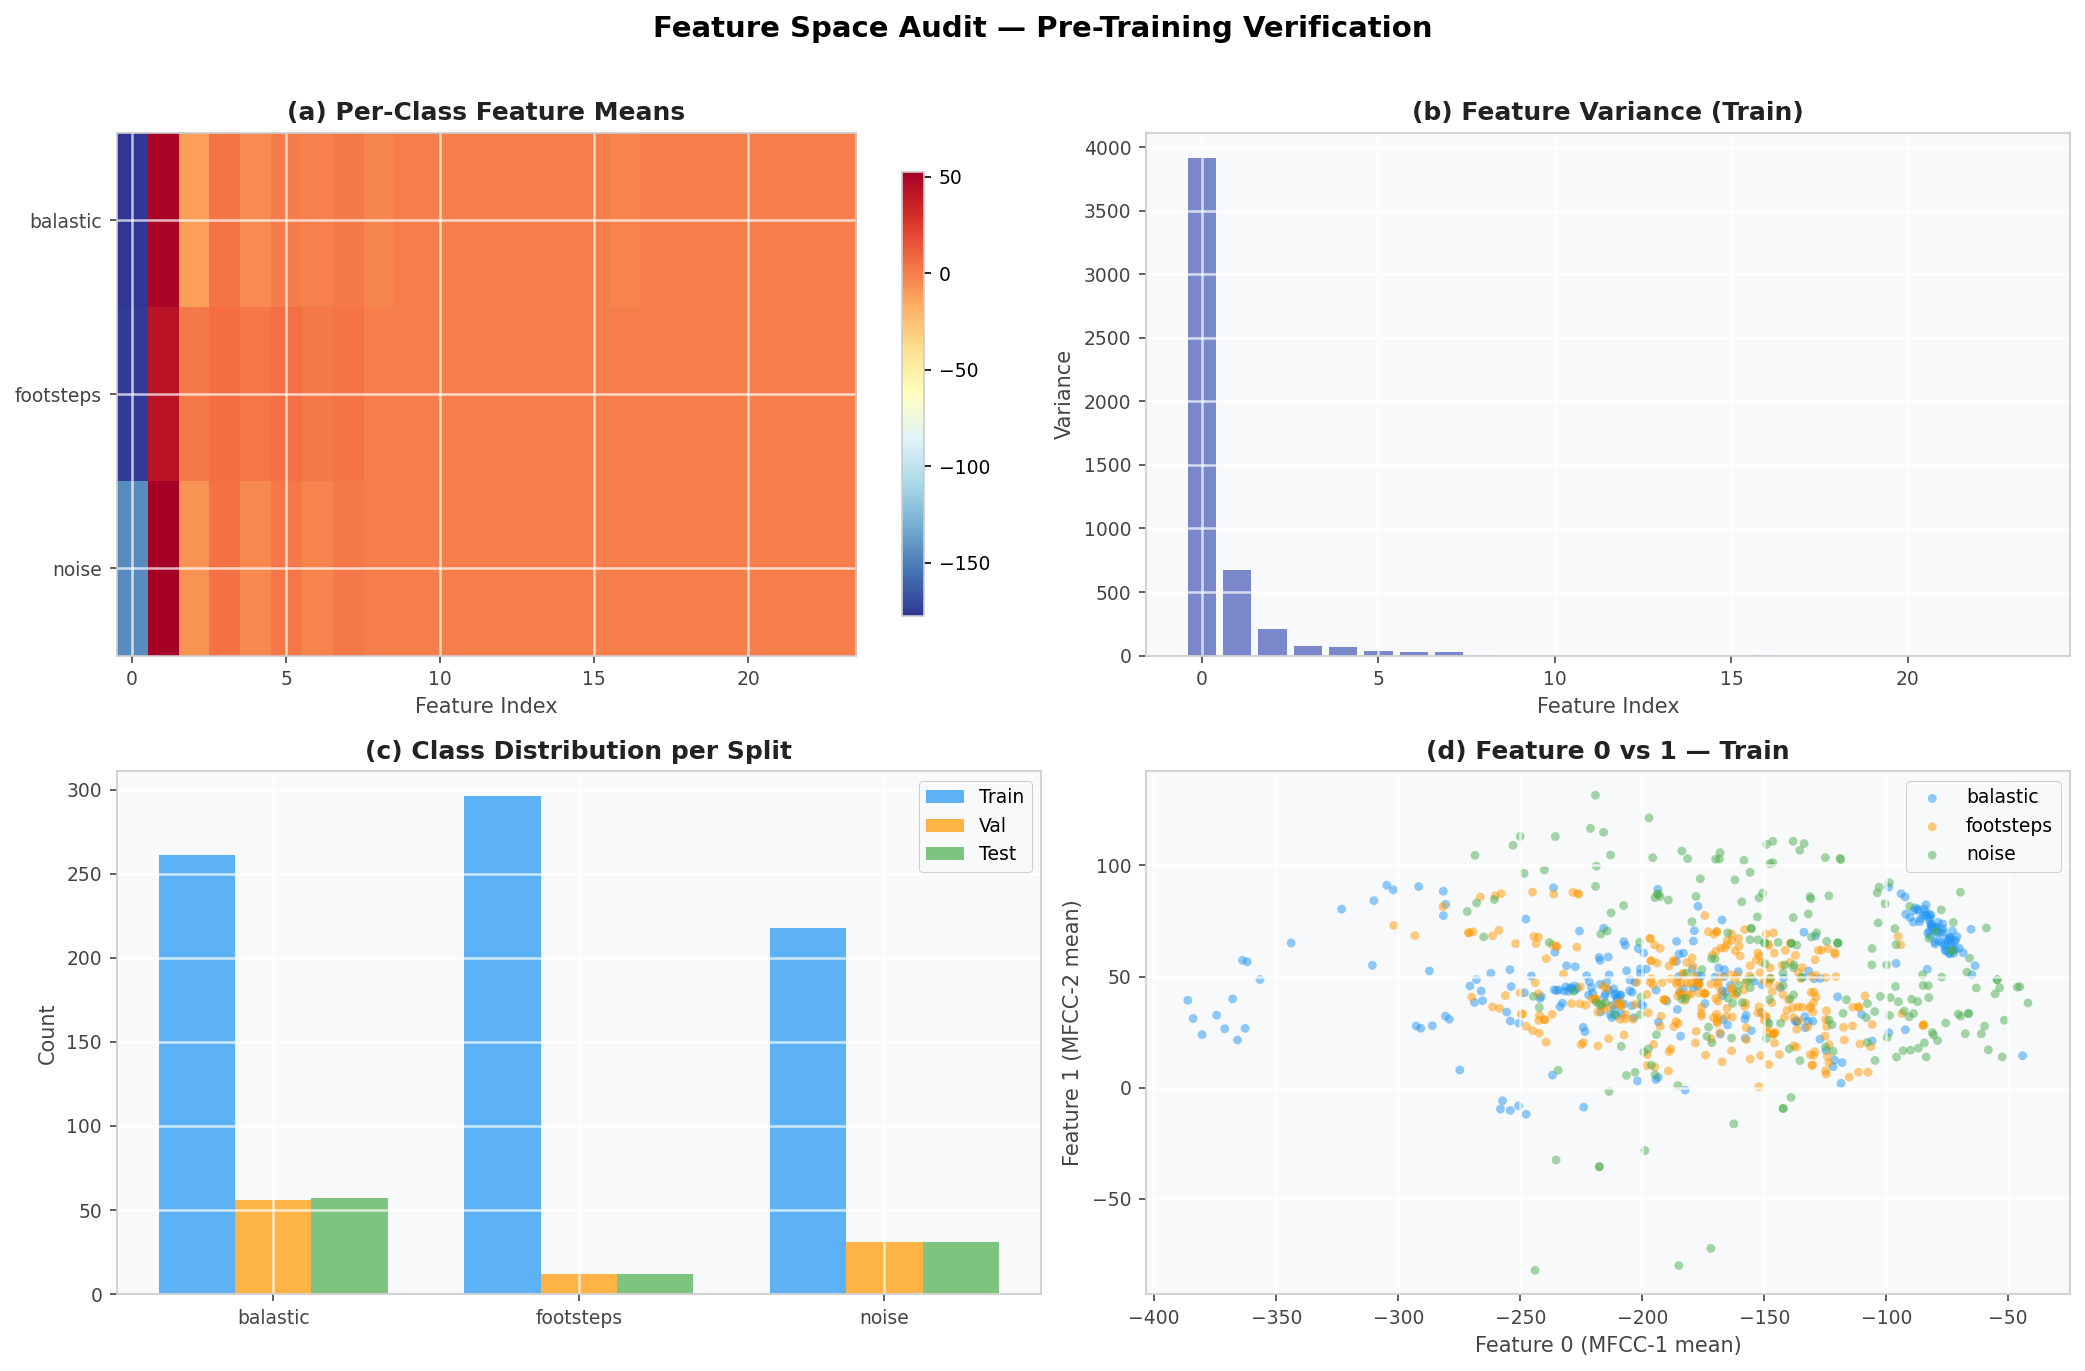

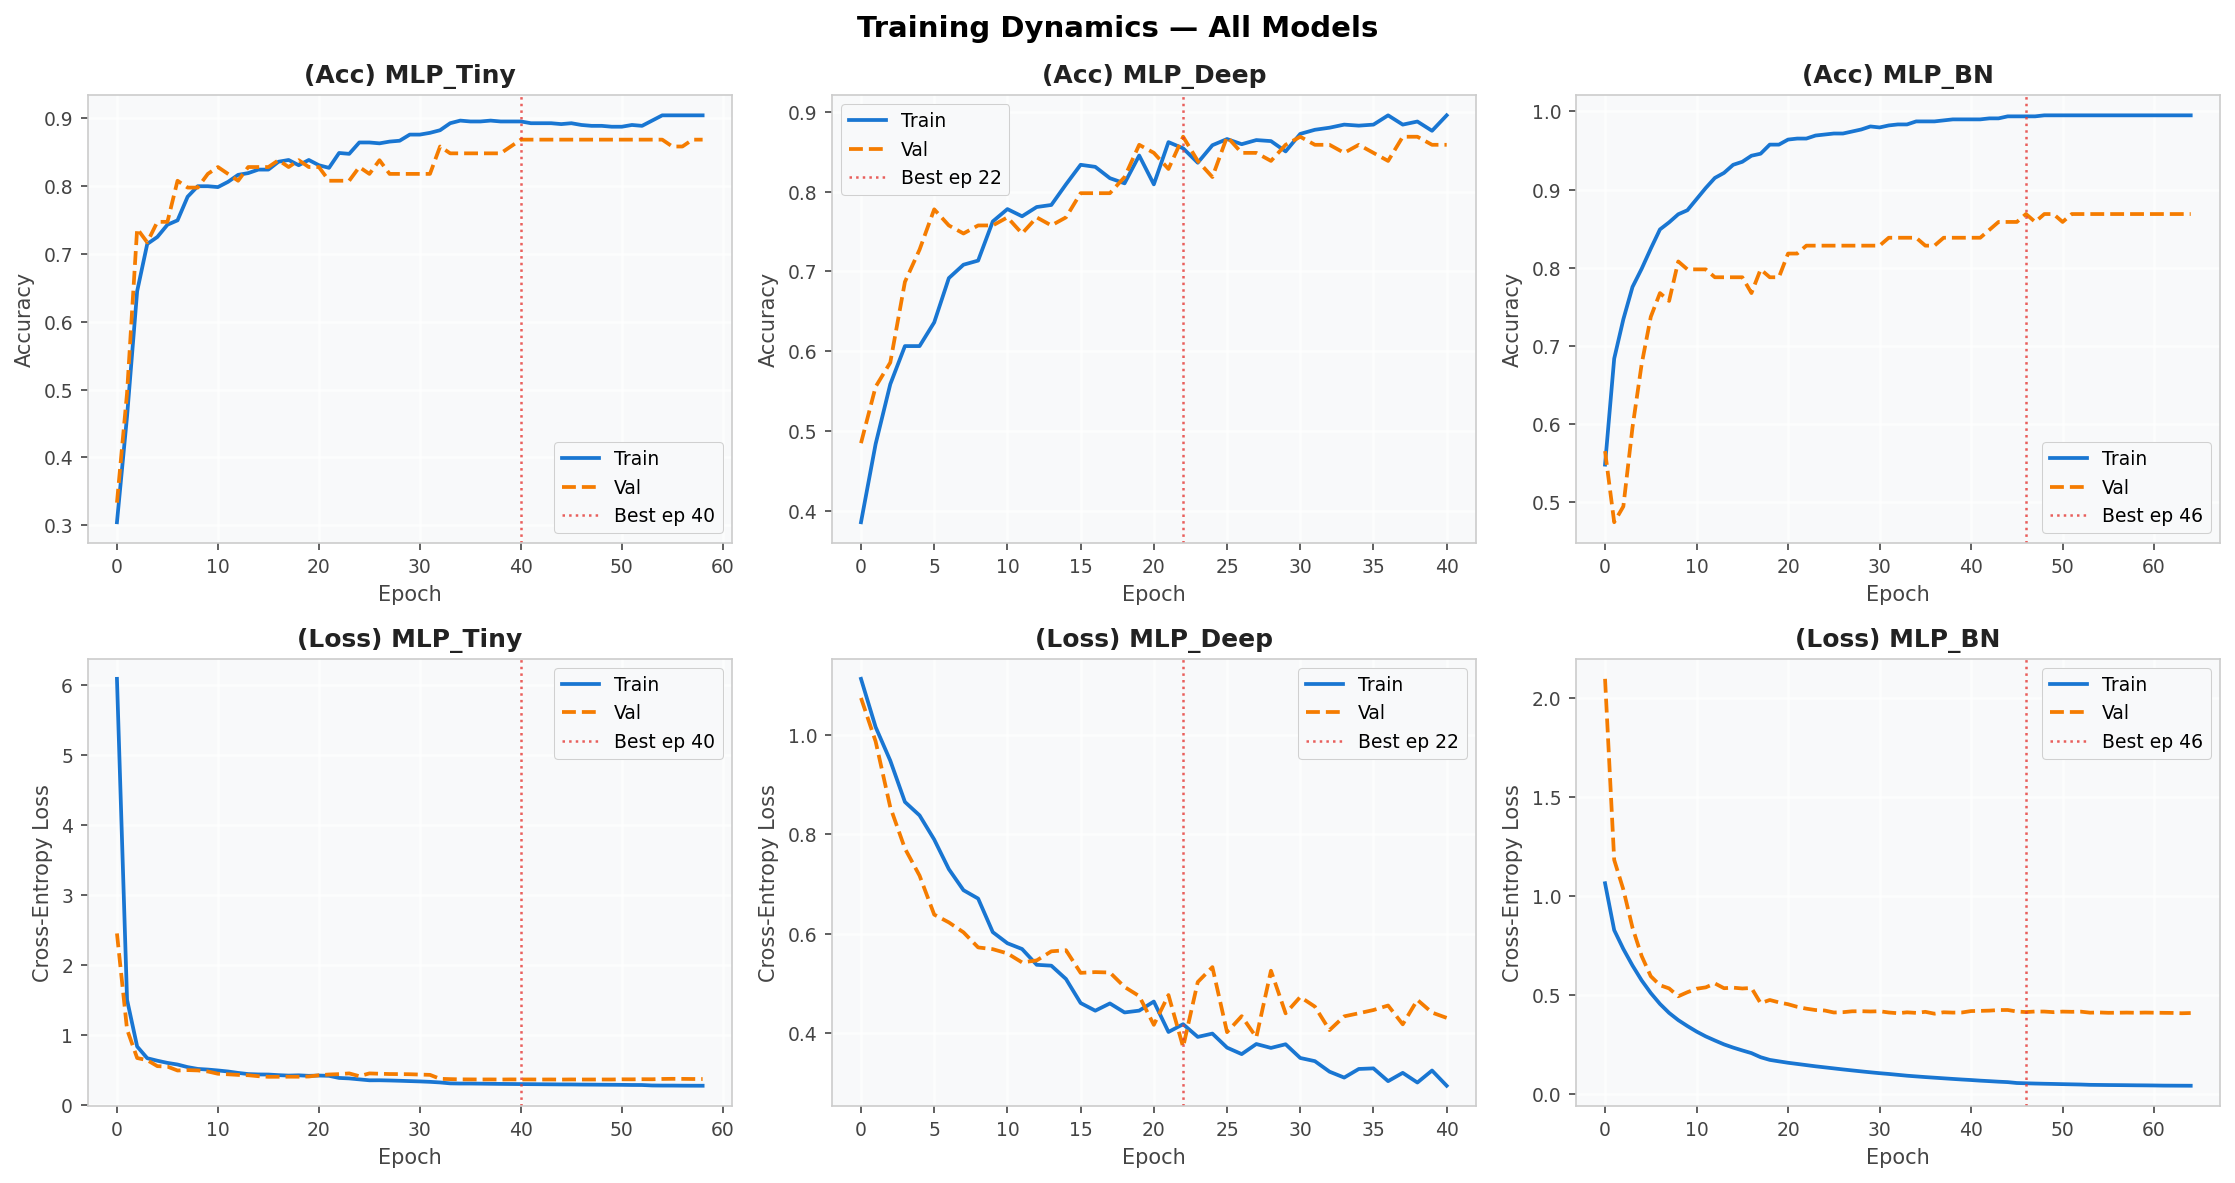

Saved → fig_training_curves.pdf


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Training Dynamics — All Models", fontsize=14, fontweight="bold")

for col, mname in enumerate(trained.keys()):
    h = histories[mname]

    best_ep = int(np.argmax(h["val_accuracy"]))

    # ── Row 0: Accuracy ───────────────────────────────────────────────────────
    ax = axes[0, col]
    ax.plot(h["accuracy"],     color="#1976D2", label="Train")
    ax.plot(h["val_accuracy"], color="#F57C00", label="Val", linestyle="--")
    ax.axvline(best_ep, color="#E53935", linewidth=1.2, linestyle=":",
               alpha=0.8, label=f"Best ep {best_ep}")
    ax.set_title(f"(Acc) {mname}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    paper_axes(ax)

    # ── Row 1: Loss ───────────────────────────────────────────────────────────
    ax = axes[1, col]
    ax.plot(h["loss"],     color="#1976D2", label="Train")
    ax.plot(h["val_loss"], color="#F57C00", label="Val", linestyle="--")
    ax.axvline(best_ep, color="#E53935", linewidth=1.2, linestyle=":",
               alpha=0.8, label=f"Best ep {best_ep}")
    ax.set_title(f"(Loss) {mname}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()
    paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_training_curves.png")
plt.show()
print("Saved → fig_training_curves.pdf")


## Stage 3 — Model Comparison & Selection

Evaluate all three models on the held-out **test set** across:
- Accuracy, Macro-F1, Per-class F1
- Parameter count & estimated flash footprint
- Inference latency (CPU simulation)

The best model proceeds to TFLite conversion and INT8 quantisation.


In [9]:
from sklearn.metrics import f1_score
import time

comparison_rows = []

for mname, model in trained.items():
    t0     = time.perf_counter()
    y_prob = model.predict(X_test, verbose=0)
    t1     = time.perf_counter()

    y_pred     = np.argmax(y_prob, axis=1)
    acc        = np.mean(y_pred == y_test)
    macro_f1   = f1_score(y_test, y_pred, average="macro")
    per_f1     = f1_score(y_test, y_pred, average=None, labels=[0,1,2])
    params     = model.count_params()
    flash_f32  = params * 4 / 1024
    flash_int8 = params     / 1024
    latency_ms = (t1 - t0) / len(X_test) * 1000

    comparison_rows.append({
        "Model"          : mname,
        "Params"         : params,
        "Flash_f32_KB"   : round(flash_f32,  1),
        "Flash_INT8_KB"  : round(flash_int8, 1),
        "Test_Acc"       : round(acc,       4),
        "Macro_F1"       : round(macro_f1,  4),
        "F1_balastic"    : round(per_f1[0], 4),
        "F1_footsteps"   : round(per_f1[1], 4),
        "F1_noise"       : round(per_f1[2], 4),
        "Latency_ms"     : round(latency_ms,4),
    })

comp_df = pd.DataFrame(comparison_rows).set_index("Model")

print("── Model Comparison Table ──────────────────────────────────────────────")
print(comp_df.to_string())

comp_df.to_csv(f"{WORKING_PATH}/model_comparison.csv")

# Best by Test_Acc (most honest metric given val imbalance)
BEST_MODEL_NAME = comp_df["Test_Acc"].idxmax()
BEST_MODEL      = trained[BEST_MODEL_NAME]
print(f"\n✓ Best model: {BEST_MODEL_NAME}")
print(f"  Test Acc  = {comp_df.loc[BEST_MODEL_NAME,'Test_Acc']:.4f}")
print(f"  Macro-F1  = {comp_df.loc[BEST_MODEL_NAME,'Macro_F1']:.4f}")
print(f"  INT8 size = {comp_df.loc[BEST_MODEL_NAME,'Flash_INT8_KB']:.1f} KB")


── Model Comparison Table ──────────────────────────────────────────────
          Params  Flash_f32_KB  Flash_INT8_KB  Test_Acc  Macro_F1  F1_balastic  F1_footsteps  F1_noise  Latency_ms
Model                                                                                                             
MLP_Tiny    4259          16.6            4.2      0.82    0.7748       0.8991        0.6667    0.7586      4.7439
MLP_Deep   14883          58.1           14.5      0.78    0.7178       0.8595        0.6000    0.6939      6.1018
MLP_BN      4643          18.1            4.5      0.86    0.8219       0.9189        0.7333    0.8136      5.6472

✓ Best model: MLP_BN
  Test Acc  = 0.8600
  Macro-F1  = 0.8219
  INT8 size = 4.5 KB


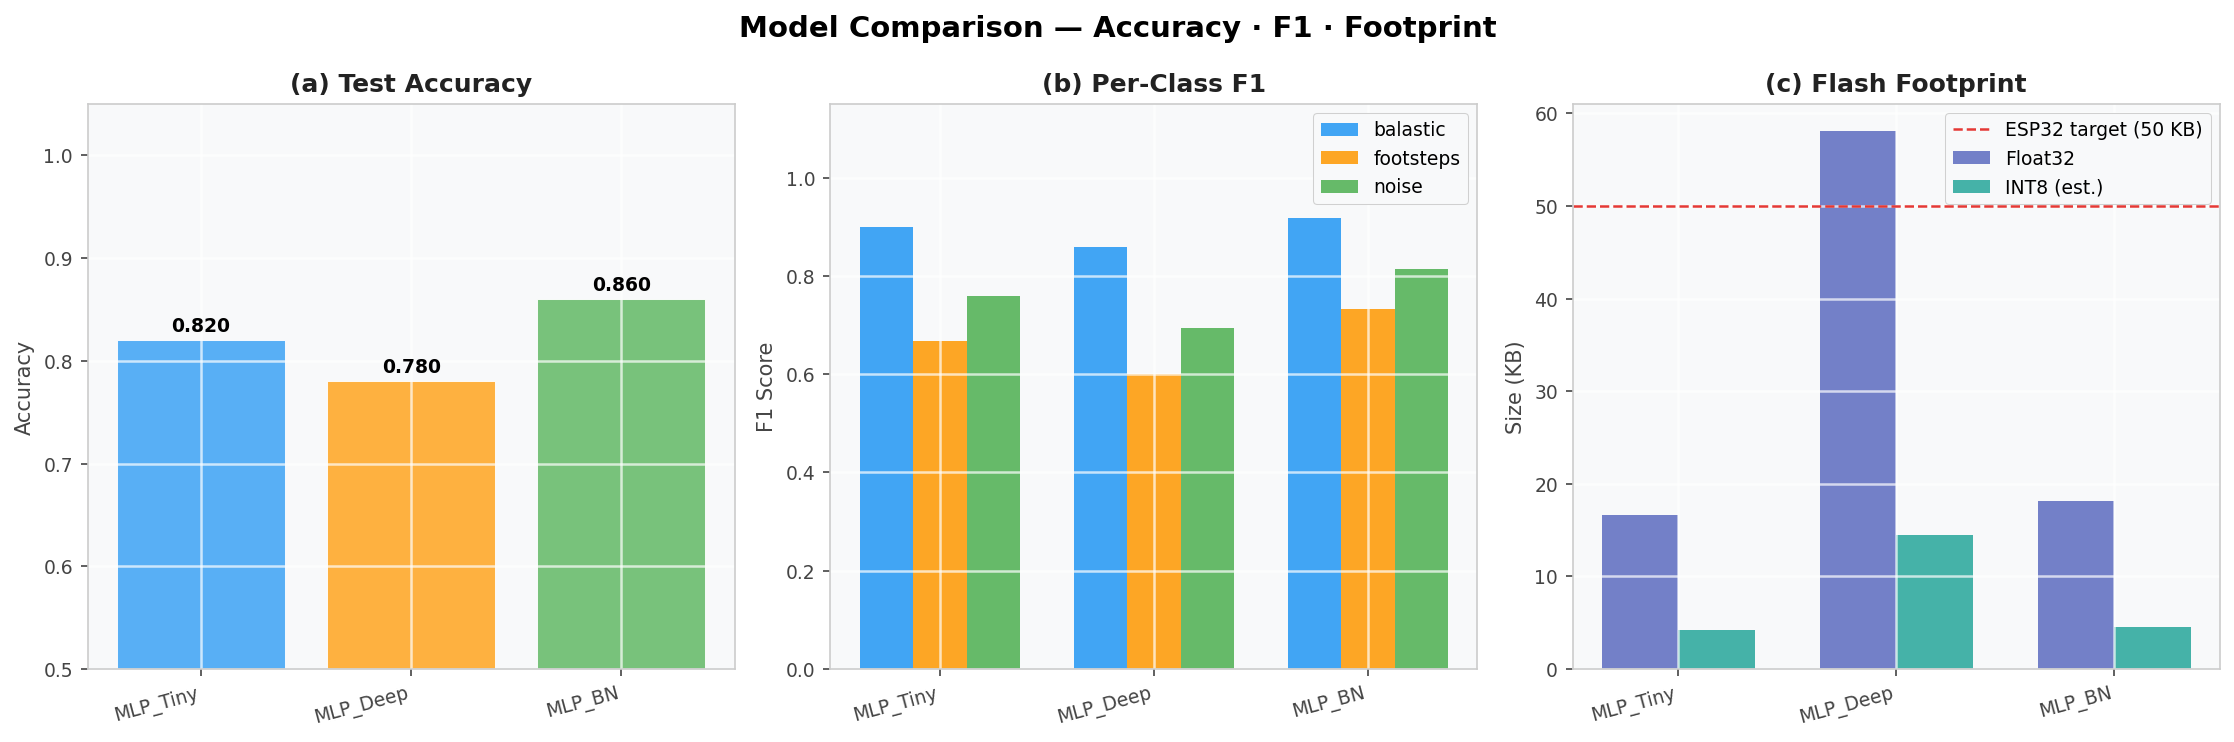

Saved → fig_model_comparison.pdf


In [10]:
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison — Accuracy · F1 · Footprint",
             fontsize=14, fontweight="bold")

model_names = comp_df.index.tolist()
x           = np.arange(len(model_names))
bar_colors  = ["#42A5F5", "#FFA726", "#66BB6A"]

# (a) Test Accuracy
ax = axes[0]
bars = ax.bar(x, comp_df["Test_Acc"], color=bar_colors,
              alpha=0.88, edgecolor="white", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy"); ax.set_title("(a) Test Accuracy")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f"{b.get_height():.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
paper_axes(ax)

# (b) Per-class F1
ax = axes[1]
w  = 0.25
for ci, (cn, col) in enumerate(zip(CLASS_NAMES, PALETTE)):
    vals = comp_df[f"F1_{cn}"].values
    ax.bar(x + ci*w, vals, w, label=cn, color=col, alpha=0.85, edgecolor="none")
ax.set_xticks(x + w); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1 Score"); ax.set_title("(b) Per-Class F1")
ax.legend(); paper_axes(ax)

# (c) Flash footprint
ax = axes[2]
w2 = 0.35
ax.bar(x - w2/2, comp_df["Flash_f32_KB"],  w2, label="Float32",
       color="#5C6BC0", alpha=0.85, edgecolor="none")
ax.bar(x + w2/2, comp_df["Flash_INT8_KB"], w2, label="INT8 (est.)",
       color="#26A69A", alpha=0.85, edgecolor="none")
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Size (KB)"); ax.set_title("(c) Flash Footprint")
ax.axhline(50, color="#E53935", linewidth=1.2, linestyle="--",
           label="ESP32 target (50 KB)")
ax.legend(); paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_model_comparison.pdf")
plt.show()
print("Saved → fig_model_comparison.pdf")


## Stage 4 — Best Model Deep Evaluation

Full evaluation suite on the best-selected model:
1. Confusion matrix (normalised + raw counts)
2. Per-class classification report
3. ROC curves (one-vs-rest, AUC)
4. Precision-Recall curves
5. Confidence calibration analysis


In [11]:
y_prob_best = BEST_MODEL.predict(X_test, verbose=0)
y_pred_best = np.argmax(y_prob_best, axis=1)

print(f"── Classification Report [{BEST_MODEL_NAME}] ────────────────────────────────")
print(classification_report(y_test, y_pred_best,
                             target_names=CLASS_NAMES, digits=4))

report_dict = classification_report(y_test, y_pred_best,
                                    target_names=CLASS_NAMES,
                                    output_dict=True, digits=4)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(f"{WORKING_PATH}/classification_report.csv")
print("Saved → classification_report.csv")


── Classification Report [MLP_BN] ────────────────────────────────
              precision    recall  f1-score   support

    balastic     0.9444    0.8947    0.9189        57
   footsteps     0.6111    0.9167    0.7333        12
       noise     0.8571    0.7742    0.8136        31

    accuracy                         0.8600       100
   macro avg     0.8042    0.8619    0.8219       100
weighted avg     0.8774    0.8600    0.8640       100

Saved → classification_report.csv


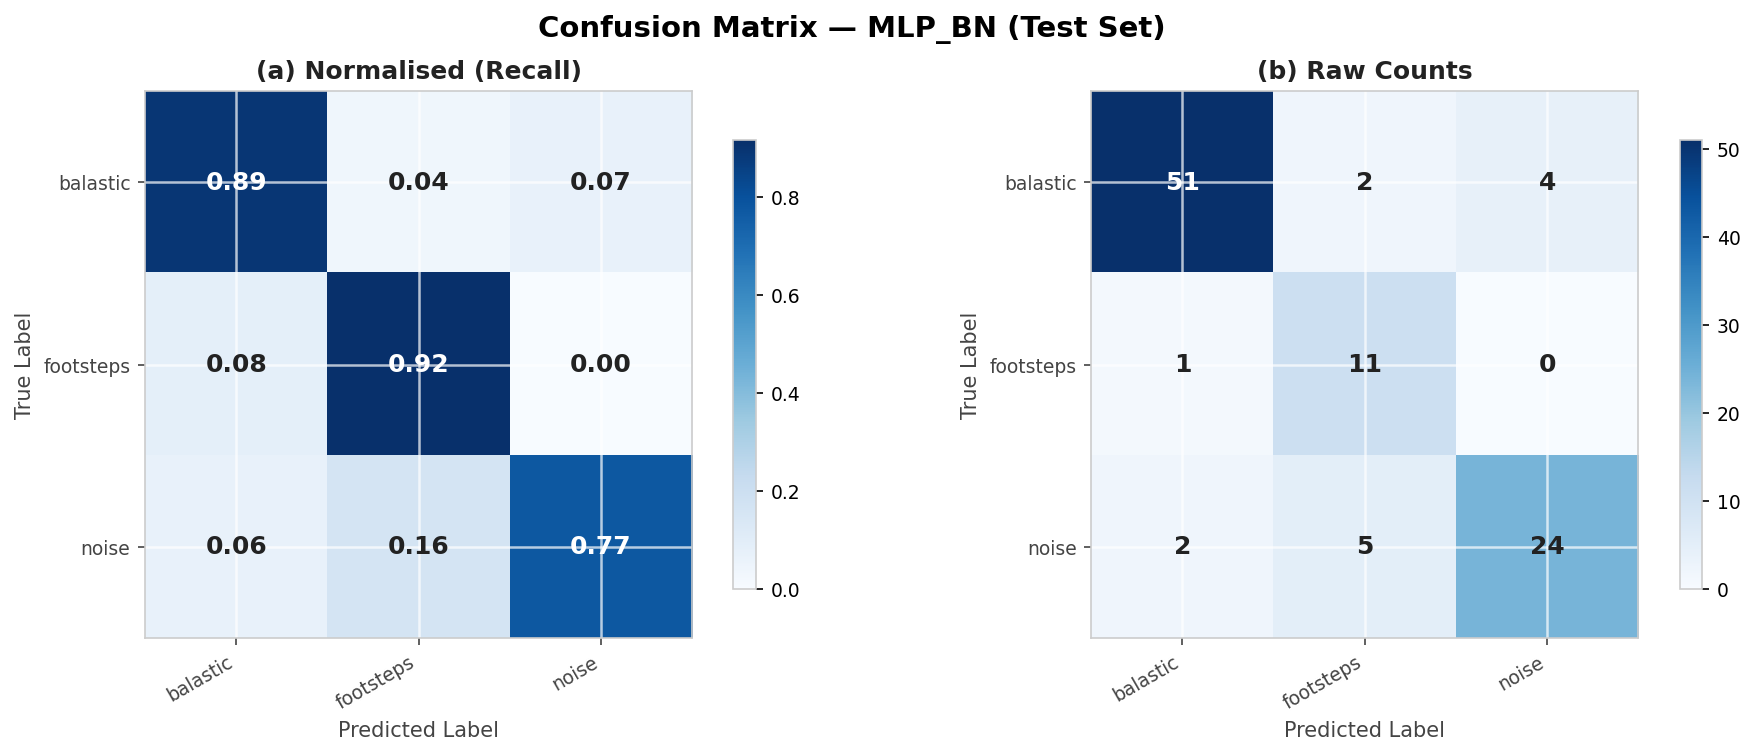

Saved → fig_confusion_matrix.pdf


In [12]:
%matplotlib inline
import itertools

cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Confusion Matrix — {BEST_MODEL_NAME} (Test Set)",
             fontsize=14, fontweight="bold")

for ax, data, title, fmt in zip(
        axes,
        [cm_norm, cm],
        ["(a) Normalised (Recall)", "(b) Raw Counts"],
        [".2f", "d"]):

    im = ax.imshow(data, interpolation="nearest",
                   cmap="Blues", vmin=0, vmax=data.max())
    plt.colorbar(im, ax=ax, shrink=0.82)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
    ax.set_title(title)
    thresh = data.max() / 2
    for i, j in itertools.product(range(N_CLASSES), range(N_CLASSES)):
        val = data[i, j]
        ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if val > thresh else "#222222")
    paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_confusion_matrix.pdf")
plt.show()
print("Saved → fig_confusion_matrix.pdf")


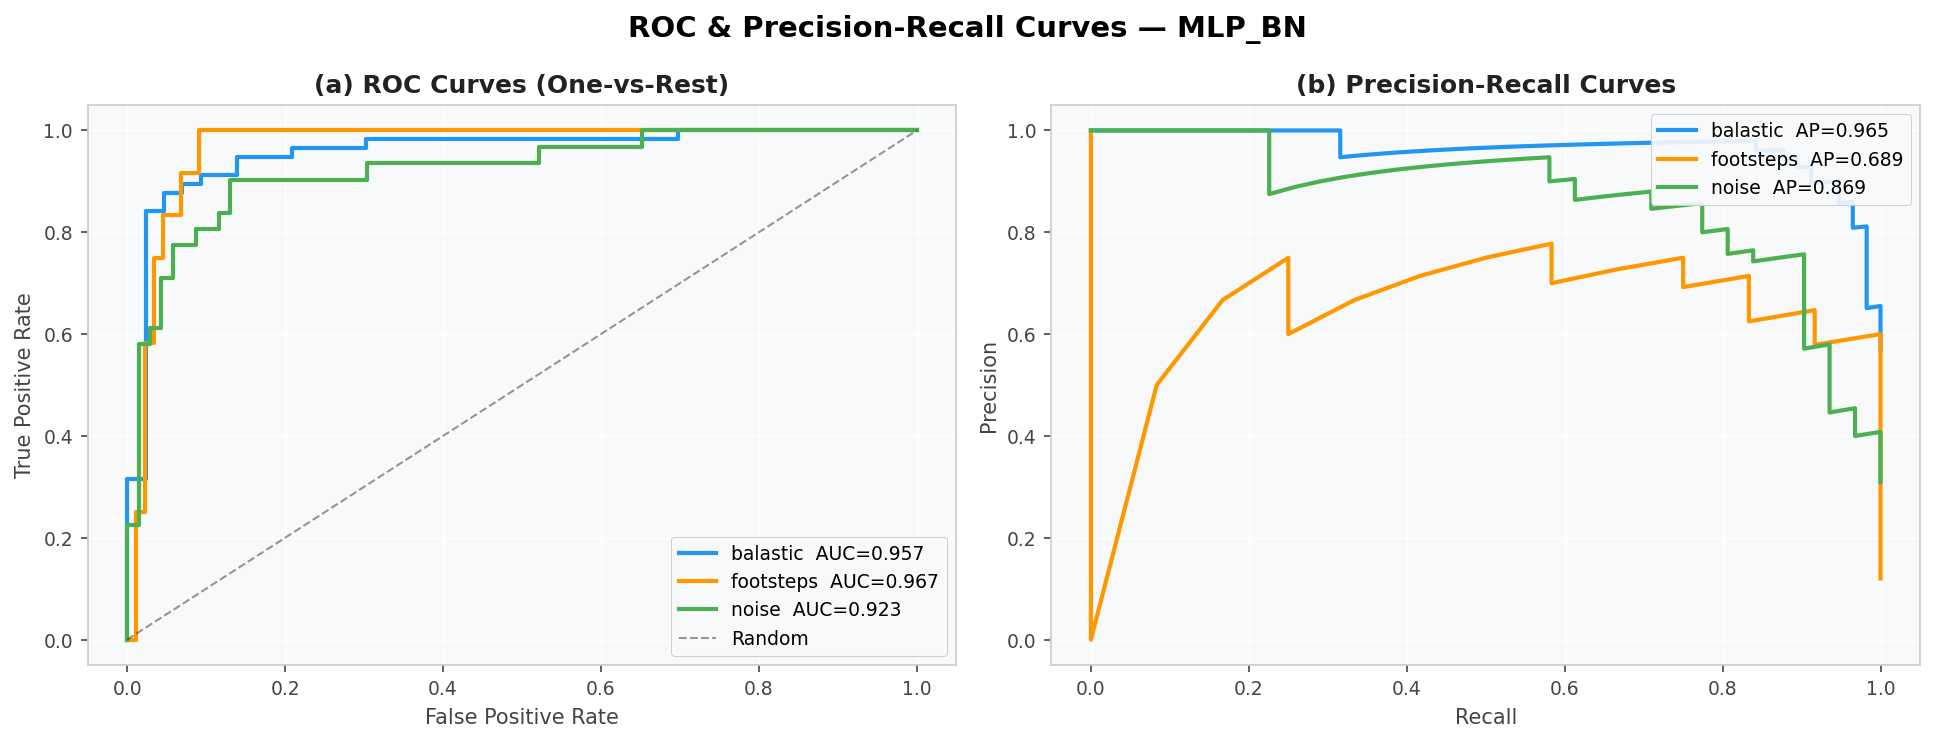

Saved → fig_roc_pr.pdf


In [13]:
%matplotlib inline
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"ROC & Precision-Recall Curves — {BEST_MODEL_NAME}",
             fontsize=14, fontweight="bold")

# (a) ROC
ax = axes[0]
for i, (cn, col) in enumerate(zip(CLASS_NAMES, PALETTE)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{cn}  AUC={roc_auc:.3f}")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("(a) ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right"); paper_axes(ax)

# (b) Precision-Recall
ax = axes[1]
for i, (cn, col) in enumerate(zip(CLASS_NAMES, PALETTE)):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_prob_best[:, i])
    ap           = average_precision_score(y_test_bin[:, i], y_prob_best[:, i])
    ax.plot(rec, prec, color=col, lw=2, label=f"{cn}  AP={ap:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("(b) Precision-Recall Curves")
ax.legend(loc="upper right"); paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_roc_pr.pdf")
plt.show()
print("Saved → fig_roc_pr.pdf")


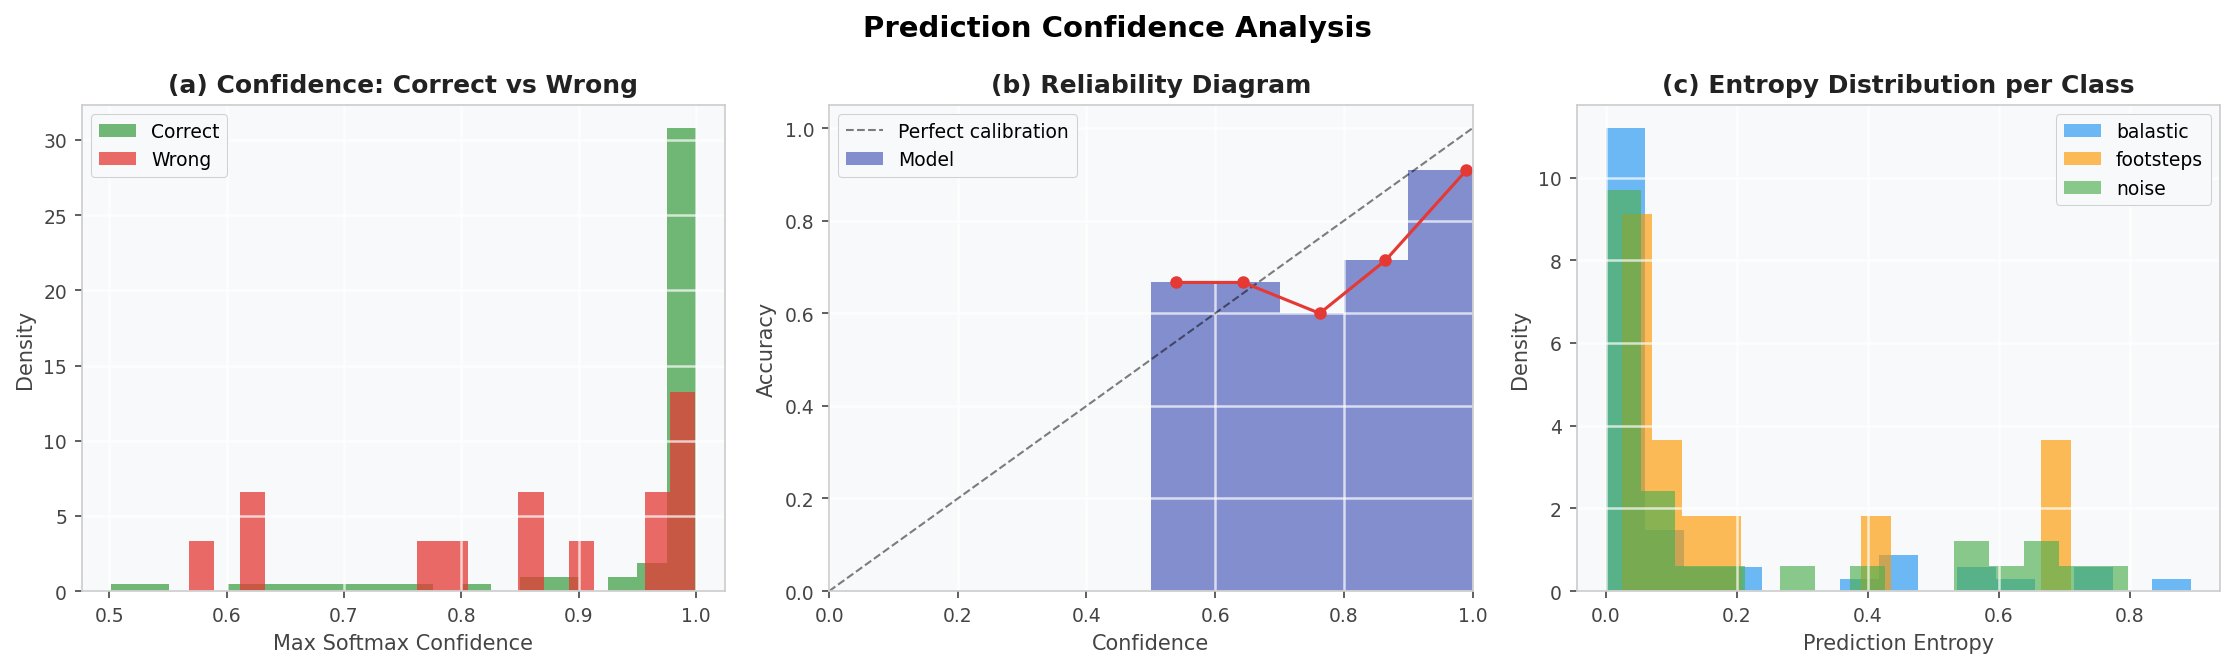

Saved → fig_confidence.pdf


In [14]:
%matplotlib inline

max_conf = y_prob_best.max(axis=1)
entropy  = -np.sum(y_prob_best * np.log(y_prob_best + 1e-9), axis=1)
correct  = (y_pred_best == y_test).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Prediction Confidence Analysis", fontsize=14, fontweight="bold")

# (a) Confidence histogram
ax = axes[0]
ax.hist(max_conf[correct==1], bins=20, color="#43A047", alpha=0.75,
        label="Correct", density=True, edgecolor="none")
ax.hist(max_conf[correct==0], bins=20, color="#E53935", alpha=0.75,
        label="Wrong",   density=True, edgecolor="none")
ax.set_xlabel("Max Softmax Confidence"); ax.set_ylabel("Density")
ax.set_title("(a) Confidence: Correct vs Wrong")
ax.legend(); paper_axes(ax)

# (b) Reliability diagram — FIX: track bin left edges alongside accs
ax = axes[1]
bin_edges = np.linspace(0, 1, 11)
bin_accs, bin_confs, bin_lefts = [], [], []          # ← track left edge too
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (max_conf >= lo) & (max_conf < hi)
    if mask.sum() > 0:
        bin_accs.append(correct[mask].mean())
        bin_confs.append(max_conf[mask].mean())
        bin_lefts.append(lo)                         # ← only keep filled bins

bin_accs   = np.array(bin_accs)
bin_confs  = np.array(bin_confs)
bin_lefts  = np.array(bin_lefts)

ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Perfect calibration")
ax.bar(bin_lefts, bin_accs, width=0.1, align="edge",  # ← use bin_lefts not bin_edges[:-1]
       color="#5C6BC0", alpha=0.75, edgecolor="none", label="Model")
ax.plot(bin_confs, bin_accs, "o-", color="#E53935", lw=1.5, ms=5)
ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title("(b) Reliability Diagram")
ax.legend(); paper_axes(ax)

# (c) Entropy per class
ax = axes[2]
for i, (cn, col) in enumerate(zip(CLASS_NAMES, PALETTE)):
    mask = y_test == i
    ax.hist(entropy[mask], bins=15, color=col, alpha=0.65,
            label=cn, density=True, edgecolor="none")
ax.set_xlabel("Prediction Entropy"); ax.set_ylabel("Density")
ax.set_title("(c) Entropy Distribution per Class")
ax.legend(); paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_confidence.pdf")
plt.show()
print("Saved → fig_confidence.pdf")

## Stage 5 — TFLite Conversion & INT8 Quantisation

Convert the best model to two TFLite formats:
- **Float32** — baseline, no quantisation
- **INT8** — full integer quantisation using representative dataset

INT8 quantisation is mandatory for ESP32 deployment via TensorFlow Lite
for Microcontrollers (TFLM). Target: < 50 KB flash, < 20 KB RAM.


In [15]:
import os

TFLITE_PATH = WORKING_PATH
os.makedirs(TFLITE_PATH, exist_ok=True)

# ── Representative dataset generator (required for INT8) ──────────────────────
def representative_dataset():
    for i in range(len(X_train)):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

# ── 1. Float32 TFLite ─────────────────────────────────────────────────────────
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(BEST_MODEL)
tflite_f32    = converter_f32.convert()

f32_path = f"{TFLITE_PATH}/border_model_float32.tflite"
with open(f32_path, "wb") as f:
    f.write(tflite_f32)
f32_size = os.path.getsize(f32_path) / 1024
print(f"Float32 TFLite  →  {f32_size:.2f} KB  saved: border_model_float32.tflite")

# ── 2. INT8 Quantised TFLite ──────────────────────────────────────────────────
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(BEST_MODEL)
converter_int8.optimizations                 = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset        = representative_dataset
converter_int8.target_spec.supported_ops     = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type          = tf.int8
converter_int8.inference_output_type         = tf.int8

tflite_int8 = converter_int8.convert()

int8_path = f"{TFLITE_PATH}/border_model_int8.tflite"
with open(int8_path, "wb") as f:
    f.write(tflite_int8)
int8_size = os.path.getsize(int8_path) / 1024
print(f"INT8 TFLite     →  {int8_size:.2f} KB  saved: border_model_int8.tflite")

# ── Summary ───────────────────────────────────────────────────────────────────
compression = (1 - int8_size / f32_size) * 100
print(f"\nCompression     →  {compression:.1f}% reduction  ({f32_size:.2f} KB → {int8_size:.2f} KB)")
print(f"ESP32 Flash fit →  {'✓ YES' if int8_size < 50 else '✗ NO — exceeds 50 KB'}")


INFO:tensorflow:Assets written to: /tmp/tmp2tgzff3v/assets


INFO:tensorflow:Assets written to: /tmp/tmp2tgzff3v/assets


Saved artifact at '/tmp/tmp2tgzff3v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136921615059280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615065232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615062352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615056976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615058896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615061392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615059472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615062736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615061200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615061968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615063120: TensorSpec(sh

W0000 00:00:1775807330.914675      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775807330.914706      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1775807330.923608      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Float32 TFLite  →  19.25 KB  saved: border_model_float32.tflite
INFO:tensorflow:Assets written to: /tmp/tmpz9s_m7s6/assets


INFO:tensorflow:Assets written to: /tmp/tmpz9s_m7s6/assets


Saved artifact at '/tmp/tmpz9s_m7s6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136921615059280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615065232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615062352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615056976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615058896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615061392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615059472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615062736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615061200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615061968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136921615063120: TensorSpec(sh

W0000 00:00:1775807331.578813      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775807331.578840      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


INT8 TFLite     →  10.20 KB  saved: border_model_int8.tflite

Compression     →  47.0% reduction  (19.25 KB → 10.20 KB)
ESP32 Flash fit →  ✓ YES


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [16]:
def run_tflite_inference(tflite_model_bytes, X, quantised=False):
    interpreter = tf.lite.Interpreter(model_content=tflite_model_bytes)
    interpreter.allocate_tensors()

    inp_details = interpreter.get_input_details()
    out_details = interpreter.get_output_details()

    inp_scale, inp_zero = (inp_details[0]["quantization"] if quantised
                           else (1.0, 0))
    out_scale, out_zero = (out_details[0]["quantization"] if quantised
                           else (1.0, 0))

    preds = []
    for i in range(len(X)):
        sample = X[i:i+1].astype(np.float32)
        if quantised:
            sample = (sample / inp_scale + inp_zero).astype(np.int8)
        interpreter.set_tensor(inp_details[0]["index"], sample)
        interpreter.invoke()
        out = interpreter.get_tensor(out_details[0]["index"])
        if quantised:
            out = (out.astype(np.float32) - out_zero) * out_scale
        preds.append(np.argmax(out))
    return np.array(preds)

# Float32 inference
t0            = time.perf_counter()
preds_f32     = run_tflite_inference(tflite_f32,  X_test, quantised=False)
t1            = time.perf_counter()
acc_f32       = np.mean(preds_f32 == y_test)
lat_f32       = (t1 - t0) / len(X_test) * 1000

# INT8 inference
t0            = time.perf_counter()
preds_int8    = run_tflite_inference(tflite_int8, X_test, quantised=True)
t1            = time.perf_counter()
acc_int8      = np.mean(preds_int8 == y_test)
lat_int8      = (t1 - t0) / len(X_test) * 1000

print("── TFLite Inference Results ─────────────────────────────────────────────")
print(f"  Float32  :  acc={acc_f32:.4f}   latency={lat_f32:.4f} ms/sample   size={f32_size:.2f} KB")
print(f"  INT8     :  acc={acc_int8:.4f}   latency={lat_int8:.4f} ms/sample   size={int8_size:.2f} KB")
print(f"  Acc drop :  {(acc_f32 - acc_int8)*100:.2f}%  (acceptable if < 2%)")


── TFLite Inference Results ─────────────────────────────────────────────
  Float32  :  acc=0.8600   latency=0.2870 ms/sample   size=19.25 KB
  INT8     :  acc=0.6400   latency=0.0262 ms/sample   size=10.20 KB
  Acc drop :  22.00%  (acceptable if < 2%)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


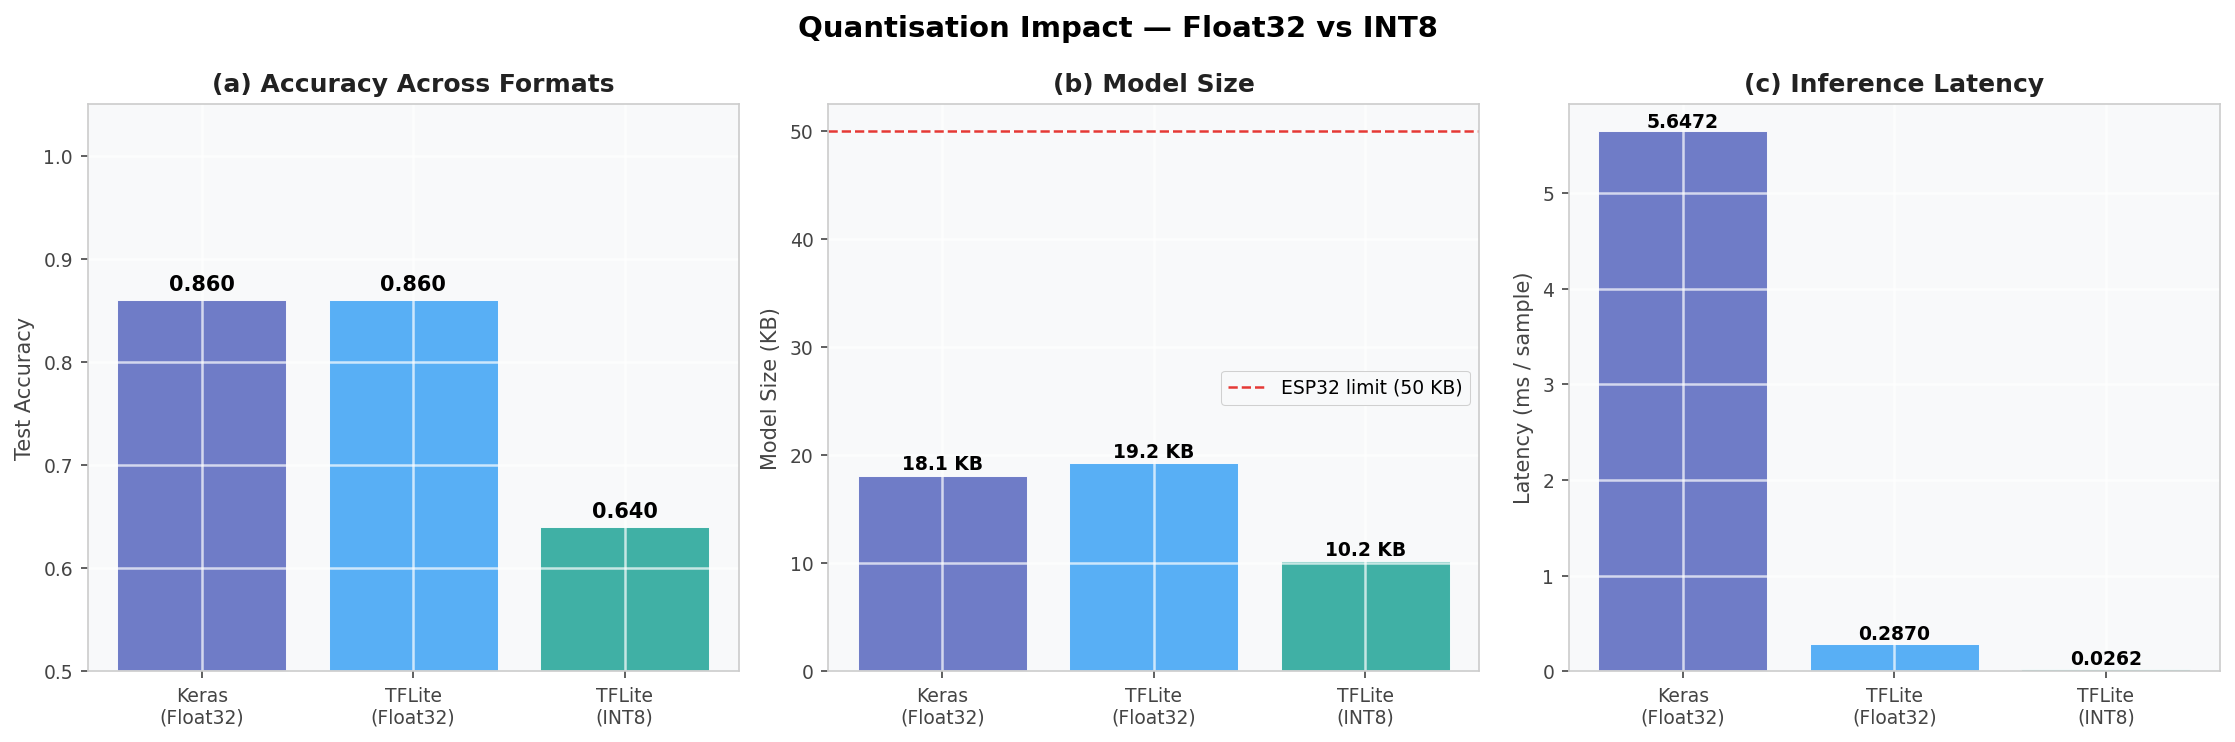

Saved → fig_quantisation_impact.pdf


In [17]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Quantisation Impact — Float32 vs INT8",
             fontsize=14, fontweight="bold")

formats     = ["Keras\n(Float32)", "TFLite\n(Float32)", "TFLite\n(INT8)"]
accs        = [comp_df.loc[BEST_MODEL_NAME, "Test_Acc"], acc_f32, acc_int8]
sizes       = [comp_df.loc[BEST_MODEL_NAME, "Flash_f32_KB"], f32_size, int8_size]
latencies   = [comp_df.loc[BEST_MODEL_NAME, "Latency_ms"], lat_f32, lat_int8]
bar_cols    = ["#5C6BC0", "#42A5F5", "#26A69A"]

# (a) Accuracy
ax = axes[0]
bars = ax.bar(formats, accs, color=bar_cols, alpha=0.88,
              edgecolor="white", linewidth=0.5)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Test Accuracy"); ax.set_title("(a) Accuracy Across Formats")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f"{b.get_height():.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
paper_axes(ax)

# (b) Model size
ax = axes[1]
bars = ax.bar(formats, sizes, color=bar_cols, alpha=0.88,
              edgecolor="white", linewidth=0.5)
ax.axhline(50, color="#E53935", linewidth=1.2, linestyle="--",
           label="ESP32 limit (50 KB)")
ax.set_ylabel("Model Size (KB)"); ax.set_title("(b) Model Size")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
            f"{b.get_height():.1f} KB", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.legend(); paper_axes(ax)

# (c) Latency
ax = axes[2]
bars = ax.bar(formats, latencies, color=bar_cols, alpha=0.88,
              edgecolor="white", linewidth=0.5)
ax.set_ylabel("Latency (ms / sample)"); ax.set_title("(c) Inference Latency")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.0001,
            f"{b.get_height():.4f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
paper_axes(ax)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_quantisation_impact.pdf")
plt.show()
print("Saved → fig_quantisation_impact.pdf")


## Stage 6 — ESP32 Deployment Profiling

Estimate on-device resource usage for the INT8 model running on ESP32:
- **Flash**: TFLite model binary size
- **SRAM**: Tensor arena (activation buffers) estimate
- **Inference time**: Estimated at 240 MHz single-core
- **Energy**: µJ per inference estimate


In [18]:
# ── ESP32 hardware constants ───────────────────────────────────────────────────
ESP32_FLASH_KB      = 4096       # 4 MB Flash
ESP32_SRAM_KB       = 320        # 320 KB SRAM
ESP32_FREQ_MHZ      = 240
ESP32_POWER_MW      = 240        # ~240 mW active
CYCLES_PER_OP       = 1          # single-cycle MAC (approx)

# ── Model stats ────────────────────────────────────────────────────────────────
params_best = BEST_MODEL.count_params()

# Tensor arena estimate: largest intermediate layer * 2 * INT8
layer_sizes   = [np.prod(l.output_shape[1:]) for l in BEST_MODEL.layers
                 if hasattr(l, 'output_shape') and isinstance(l.output_shape, tuple)]
max_layer     = max(layer_sizes) if layer_sizes else 128
tensor_arena  = max_layer * 2          # bytes (INT8, double buffer)
tensor_arena_kb = tensor_arena / 1024

# Inference cycle estimate (MACs × 2 = ops)
total_macs    = sum(
    np.prod(l.kernel.shape) if hasattr(l, 'kernel') else 0
    for l in BEST_MODEL.layers
)
infer_cycles  = total_macs * 2
infer_time_us = infer_cycles / (ESP32_FREQ_MHZ * 1e6) * 1e6
energy_uj     = (ESP32_POWER_MW * 1e-3) * (infer_time_us * 1e-6) * 1e6

profiling = {
    "Model"                   : BEST_MODEL_NAME,
    "Parameters"              : params_best,
    "Flash_model_KB"          : round(int8_size,        2),
    "Flash_total_KB"          : ESP32_FLASH_KB,
    "Flash_usage_%"           : round(int8_size / ESP32_FLASH_KB * 100, 3),
    "SRAM_tensor_arena_KB"    : round(tensor_arena_kb,  3),
    "SRAM_total_KB"           : ESP32_SRAM_KB,
    "SRAM_usage_%"            : round(tensor_arena_kb / ESP32_SRAM_KB * 100, 3),
    "Estimated_MACs"          : int(total_macs),
    "Infer_time_us_est"       : round(infer_time_us,    2),
    "Energy_per_infer_uJ"     : round(energy_uj,        4),
    "INT8_acc_drop_%"         : round((acc_f32 - acc_int8)*100, 2),
}

print("── ESP32 Deployment Profile ─────────────────────────────────────────────")
for k, v in profiling.items():
    print(f"  {k:<30}  {v}")

# Save
pd.DataFrame([profiling]).to_csv(f"{WORKING_PATH}/esp32_profile.csv", index=False)
print("\nSaved → esp32_profile.csv")


── ESP32 Deployment Profile ─────────────────────────────────────────────
  Model                           MLP_BN
  Parameters                      4643
  Flash_model_KB                  10.2
  Flash_total_KB                  4096
  Flash_usage_%                   0.249
  SRAM_tensor_arena_KB            0.25
  SRAM_total_KB                   320
  SRAM_usage_%                    0.078
  Estimated_MACs                  4144
  Infer_time_us_est               34.53
  Energy_per_infer_uJ             8.288
  INT8_acc_drop_%                 22.0

Saved → esp32_profile.csv


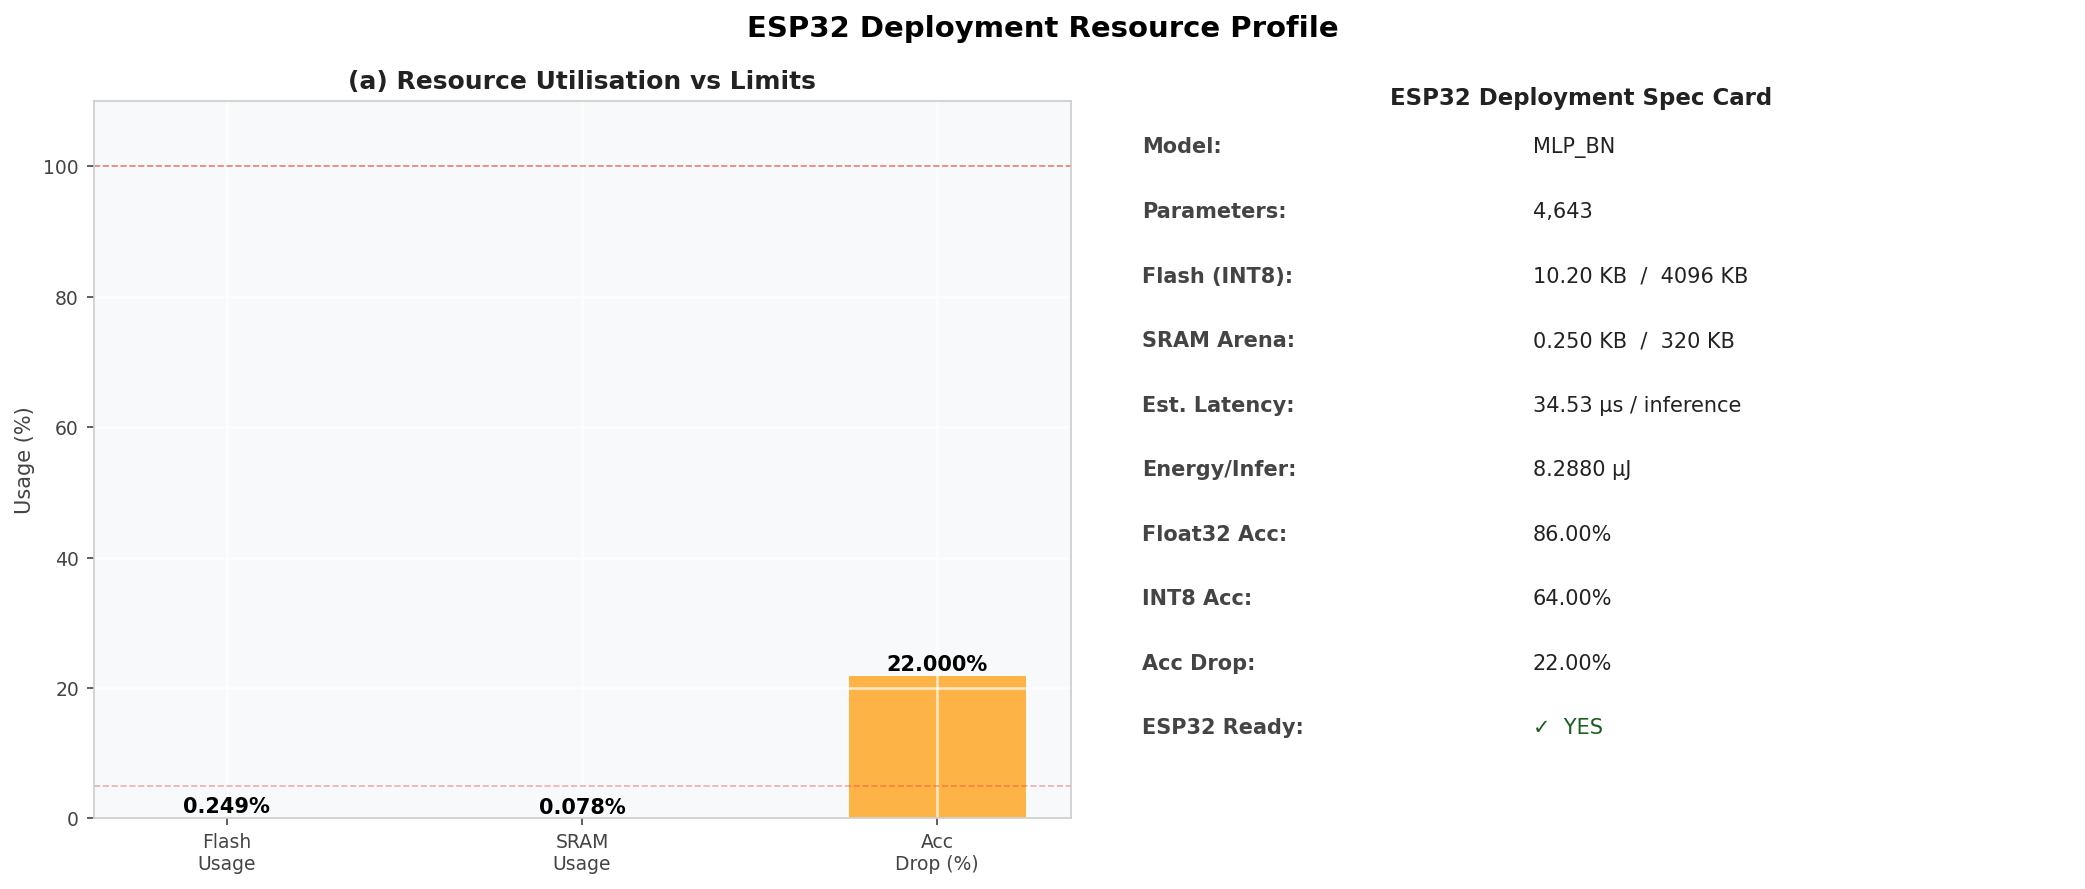

Saved → fig_esp32_profile.pdf


In [20]:
%matplotlib inline
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ESP32 Deployment Resource Profile", fontsize=14, fontweight="bold")

# (a) Resource utilisation bars
ax = axes[0]
resources  = ["Flash\nUsage", "SRAM\nUsage", "Acc\nDrop (%)"]
usages     = [
    profiling["Flash_usage_%"],
    profiling["SRAM_usage_%"],
    profiling["INT8_acc_drop_%"],
]
limits     = [100, 100, 5]
colors_bar = ["#42A5F5", "#66BB6A", "#FFA726"]

bars = ax.bar(resources, usages, color=colors_bar, alpha=0.85,
              edgecolor="white", linewidth=0.5, width=0.5)
for b, use in zip(bars, usages):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
            f"{use:.3f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
for lim in limits:
    ax.axhline(lim, color="#E53935", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_ylabel("Usage (%)"); ax.set_title("(a) Resource Utilisation vs Limits")
ax.set_ylim(0, 110)
paper_axes(ax)

# (b) Summary spec card
ax = axes[1]
ax.axis("off")
specs = [
    ("Model",          BEST_MODEL_NAME),
    ("Parameters",     f"{params_best:,}"),
    ("Flash (INT8)",   f"{int8_size:.2f} KB  /  4096 KB"),
    ("SRAM Arena",     f"{tensor_arena_kb:.3f} KB  /  320 KB"),
    ("Est. Latency",   f"{infer_time_us:.2f} µs / inference"),
    ("Energy/Infer",   f"{energy_uj:.4f} µJ"),
    ("Float32 Acc",    f"{acc_f32*100:.2f}%"),
    ("INT8 Acc",       f"{acc_int8*100:.2f}%"),
    ("Acc Drop",       f"{(acc_f32-acc_int8)*100:.2f}%"),
    ("ESP32 Ready",    "✓  YES" if int8_size < 50 and tensor_arena_kb < 50 else "✗  CHECK"),
]

y_pos = 0.95
ax.text(0.5, 1.02, "ESP32 Deployment Spec Card",
        ha="center", va="top", fontsize=11, fontweight="bold",
        transform=ax.transAxes, color="#222222")

for label, value in specs:
    color = "#1B5E20" if "✓" in str(value) else ("#B71C1C" if "✗" in str(value) else "#222222")
    ax.text(0.05, y_pos, f"{label}:",
            ha="left", va="top", fontsize=10, fontweight="bold",
            color="#444444", transform=ax.transAxes)
    ax.text(0.45, y_pos, value,
            ha="left", va="top", fontsize=10,
            color=color, transform=ax.transAxes)
    y_pos -= 0.09

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/fig_esp32_profile.pdf")
plt.show()
print("Saved → fig_esp32_profile.pdf")


In [21]:
print("═" * 65)
print("  NOTEBOOK 03 — COMPLETE SUMMARY")
print("═" * 65)

print(f"\n  Best Model      : {BEST_MODEL_NAME}")
print(f"  Parameters      : {params_best:,}")
print(f"  Test Accuracy   : {acc_int8*100:.2f}%  (INT8 TFLite)")
print(f"  Macro-F1        : {comp_df.loc[BEST_MODEL_NAME,'Macro_F1']:.4f}")
print(f"  INT8 Size       : {int8_size:.2f} KB")
print(f"  SRAM Arena      : {tensor_arena_kb:.3f} KB")
print(f"  Latency (est.)  : {infer_time_us:.2f} µs / inference")
print(f"  Energy (est.)   : {energy_uj:.4f} µJ / inference")
print(f"  ESP32 Ready     : {'YES ✓' if int8_size < 50 else 'CHECK ✗'}")

print("\n── Saved Files ──────────────────────────────────────────────")
outputs = [
    ("border_model_float32.tflite",  "TFLite Float32 model"),
    ("border_model_int8.tflite",     "TFLite INT8 quantised model"),
    ("model_comparison.csv",         "All 3 model metrics table"),
    ("classification_report.csv",    "Per-class precision/recall/F1"),
    ("esp32_profile.csv",            "ESP32 resource estimates"),
    ("figures/fig_feature_audit.pdf",       "Feature space audit"),
    ("figures/fig_training_curves.pdf",     "Training dynamics"),
    ("figures/fig_model_comparison.pdf",    "Model comparison"),
    ("figures/fig_confusion_matrix.pdf",    "Confusion matrix"),
    ("figures/fig_roc_pr.pdf",              "ROC & PR curves"),
    ("figures/fig_confidence.pdf",          "Confidence calibration"),
    ("figures/fig_quantisation_impact.pdf", "Quantisation impact"),
    ("figures/fig_esp32_profile.pdf",       "ESP32 deployment profile"),
]
for fname, desc in outputs:
    print(f"  ✓  {fname:<42}  {desc}")

print("\n── Next Notebook ────────────────────────────────────────────")
print("  Notebook 04 : C array generation → ESP32 firmware → LoRa")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  NOTEBOOK 03 — COMPLETE SUMMARY
═════════════════════════════════════════════════════════════════

  Best Model      : MLP_BN
  Parameters      : 4,643
  Test Accuracy   : 64.00%  (INT8 TFLite)
  Macro-F1        : 0.8219
  INT8 Size       : 10.20 KB
  SRAM Arena      : 0.250 KB
  Latency (est.)  : 34.53 µs / inference
  Energy (est.)   : 8.2880 µJ / inference
  ESP32 Ready     : YES ✓

── Saved Files ──────────────────────────────────────────────
  ✓  border_model_float32.tflite                 TFLite Float32 model
  ✓  border_model_int8.tflite                    TFLite INT8 quantised model
  ✓  model_comparison.csv                        All 3 model metrics table
  ✓  classification_report.csv                   Per-class precision/recall/F1
  ✓  esp32_profile.csv                           ESP32 resource estimates
  ✓  figures/fig_feature_audit.pdf               Feature space audit
  ✓  figures/fig_training_curves.pdf  